# Notebook 2: Audio Enhancement & Evaluation

## Project: Team Communication Analysis
### GSoC 2026 — HumanAI / TRIP Lab Task

This notebook applies audio enhancement techniques to a sample from the AMI Meeting Corpus (IHM channel) to improve speech clarity in team communication recordings. The goal is to make audio cleaner so that downstream transcription models perform better.

Four methods are tested and compared:
- High-pass filter + normalization (classical baseline)
- Spectral subtraction (frequency-domain noise removal)
- Wiener filter (statistical noise suppression)
- Non-stationary noise reduction via `noisereduce` (DL-inspired spectral gating)

Each method is evaluated using five metrics: SNR, RMS, Spectral Flatness, STOI, and DNSMOS.

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import scipy.signal as signal
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [3]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "pystoi", "-q"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "noisereduce", "-q"])

from pystoi import stoi
import noisereduce as nr

print("pystoi: OK")
print("noisereduce: OK")

pystoi: OK
noisereduce: OK


In [4]:
file = "sample_input.wav"

y, sr = librosa.load(file, sr=None)
dur = librosa.get_duration(y=y, sr=sr)

print("File      :", file)
print("Sample rate:", sr, "Hz")
print("Duration  :", round(dur, 2), "s")

File      : sample_input.wav
Sample rate: 16000 Hz
Duration  : 180.0 s


In [5]:
# simulate the kind of noise present in headset recordings:
# background gaussian noise + 60Hz electrical hum (common in wired setups)

np.random.seed(42)
noise = np.random.normal(0, 0.015, len(y))

t = np.linspace(0, dur, len(y))
hum = 0.008 * np.sin(2 * np.pi * 60 * t)

y_noisy = y + noise + hum
y_noisy = np.clip(y_noisy, -1, 1).astype(np.float32)

sf.write("sample_noisy.wav", y_noisy, sr)
print("Noisy audio saved: sample_noisy.wav")

Noisy audio saved: sample_noisy.wav


## Audio Enhancement Methods

### Method 1: High-pass Filter + Normalization
Removes low-frequency noise (electrical hum, HVAC rumble below 80Hz) using a Butterworth high-pass filter, then normalizes loudness. This is the simplest classical baseline.

### Method 2: Spectral Subtraction
Estimates noise from the first few silent frames of audio, then subtracts it from the full spectrum. Works well for steady background noise but can cause musical noise artifacts if applied aggressively.

### Method 3: Wiener Filter
Computes a frequency-domain gain function based on the ratio of signal power to noise power. Produces smoother output than spectral subtraction and better preserves speech detail.

### Method 4: Non-Stationary Noise Reduction (noisereduce)
Uses spectral gating with dynamic noise estimation, unlike the classical methods above, this adapts to noise that changes over time (non-stationary), which is more realistic for team communication recordings where multiple speakers and background events occur throughout.

In [6]:
def highpass_normalize(y, sr, cutoff=80):
    nyq = sr / 2
    b, a = signal.butter(4, cutoff / nyq, btype="high")
    y_hp = signal.filtfilt(b, a, y)
    rms = np.sqrt(np.mean(y_hp ** 2))
    y_out = y_hp / (rms + 1e-10) * 0.1
    return y_out.astype(np.float32)

y_hp = highpass_normalize(y_noisy, sr)
sf.write("enhanced_highpass.wav", y_hp, sr)
print("Method 1 done → enhanced_highpass.wav")

Method 1 done → enhanced_highpass.wav


In [7]:
def spectral_subtraction(y, sr, noise_frames=10, alpha=2.0):
    D = librosa.stft(y)
    mag = np.abs(D)
    phase = np.angle(D)
    noise_est = np.mean(mag[:, :noise_frames], axis=1, keepdims=True)
    clean_mag = mag - alpha * noise_est
    clean_mag = np.maximum(clean_mag, 0.1 * mag)
    D_clean = clean_mag * np.exp(1j * phase)
    y_clean = librosa.istft(D_clean, length=len(y))
    return y_clean.astype(np.float32)

y_ss = spectral_subtraction(y_noisy, sr)
sf.write("enhanced_spectral_subtraction.wav", y_ss, sr)
print("Method 2 done → enhanced_spectral_subtraction.wav")

Method 2 done → enhanced_spectral_subtraction.wav


In [8]:
def wiener_filter(y, sr, noise_frames=10):
    D = librosa.stft(y)
    power = np.abs(D) ** 2
    noise = np.mean(power[:, :noise_frames], axis=1, keepdims=True)
    gain = power / (power + noise + 1e-10)
    D_clean = gain * D
    y_clean = librosa.istft(D_clean, length=len(y))
    return y_clean.astype(np.float32)

y_wiener = wiener_filter(y_noisy, sr)
sf.write("enhanced_wiener.wav", y_wiener, sr)
print("Method 3 done → enhanced_wiener.wav")

Method 3 done → enhanced_wiener.wav


In [9]:
# non-stationary noise reduction using spectral gating
# adapts noise estimate dynamically across the recording
# does not require a clean reference signal

y_nr = nr.reduce_noise(y=y_noisy, sr=sr, stationary=False, prop_decrease=0.9)
y_nr = y_nr.astype(np.float32)

sf.write("enhanced_noisereduce.wav", y_nr, sr)
print("Method 4 done → enhanced_noisereduce.wav")

Method 4 done → enhanced_noisereduce.wav


In [10]:
# combined pipeline: stack all classical methods in sequence
# high-pass first to remove hum, then spectral subtraction for background,
# then wiener filter to smooth the result

def enhance_audio(y, sr):
    y1 = highpass_normalize(y, sr)
    y2 = spectral_subtraction(y1, sr)
    y3 = wiener_filter(y2, sr)
    return y3

y_enhanced = enhance_audio(y_noisy, sr)
sf.write("sample_output.wav", y_enhanced, sr)
print("Combined pipeline done → sample_output.wav")

Combined pipeline done → sample_output.wav


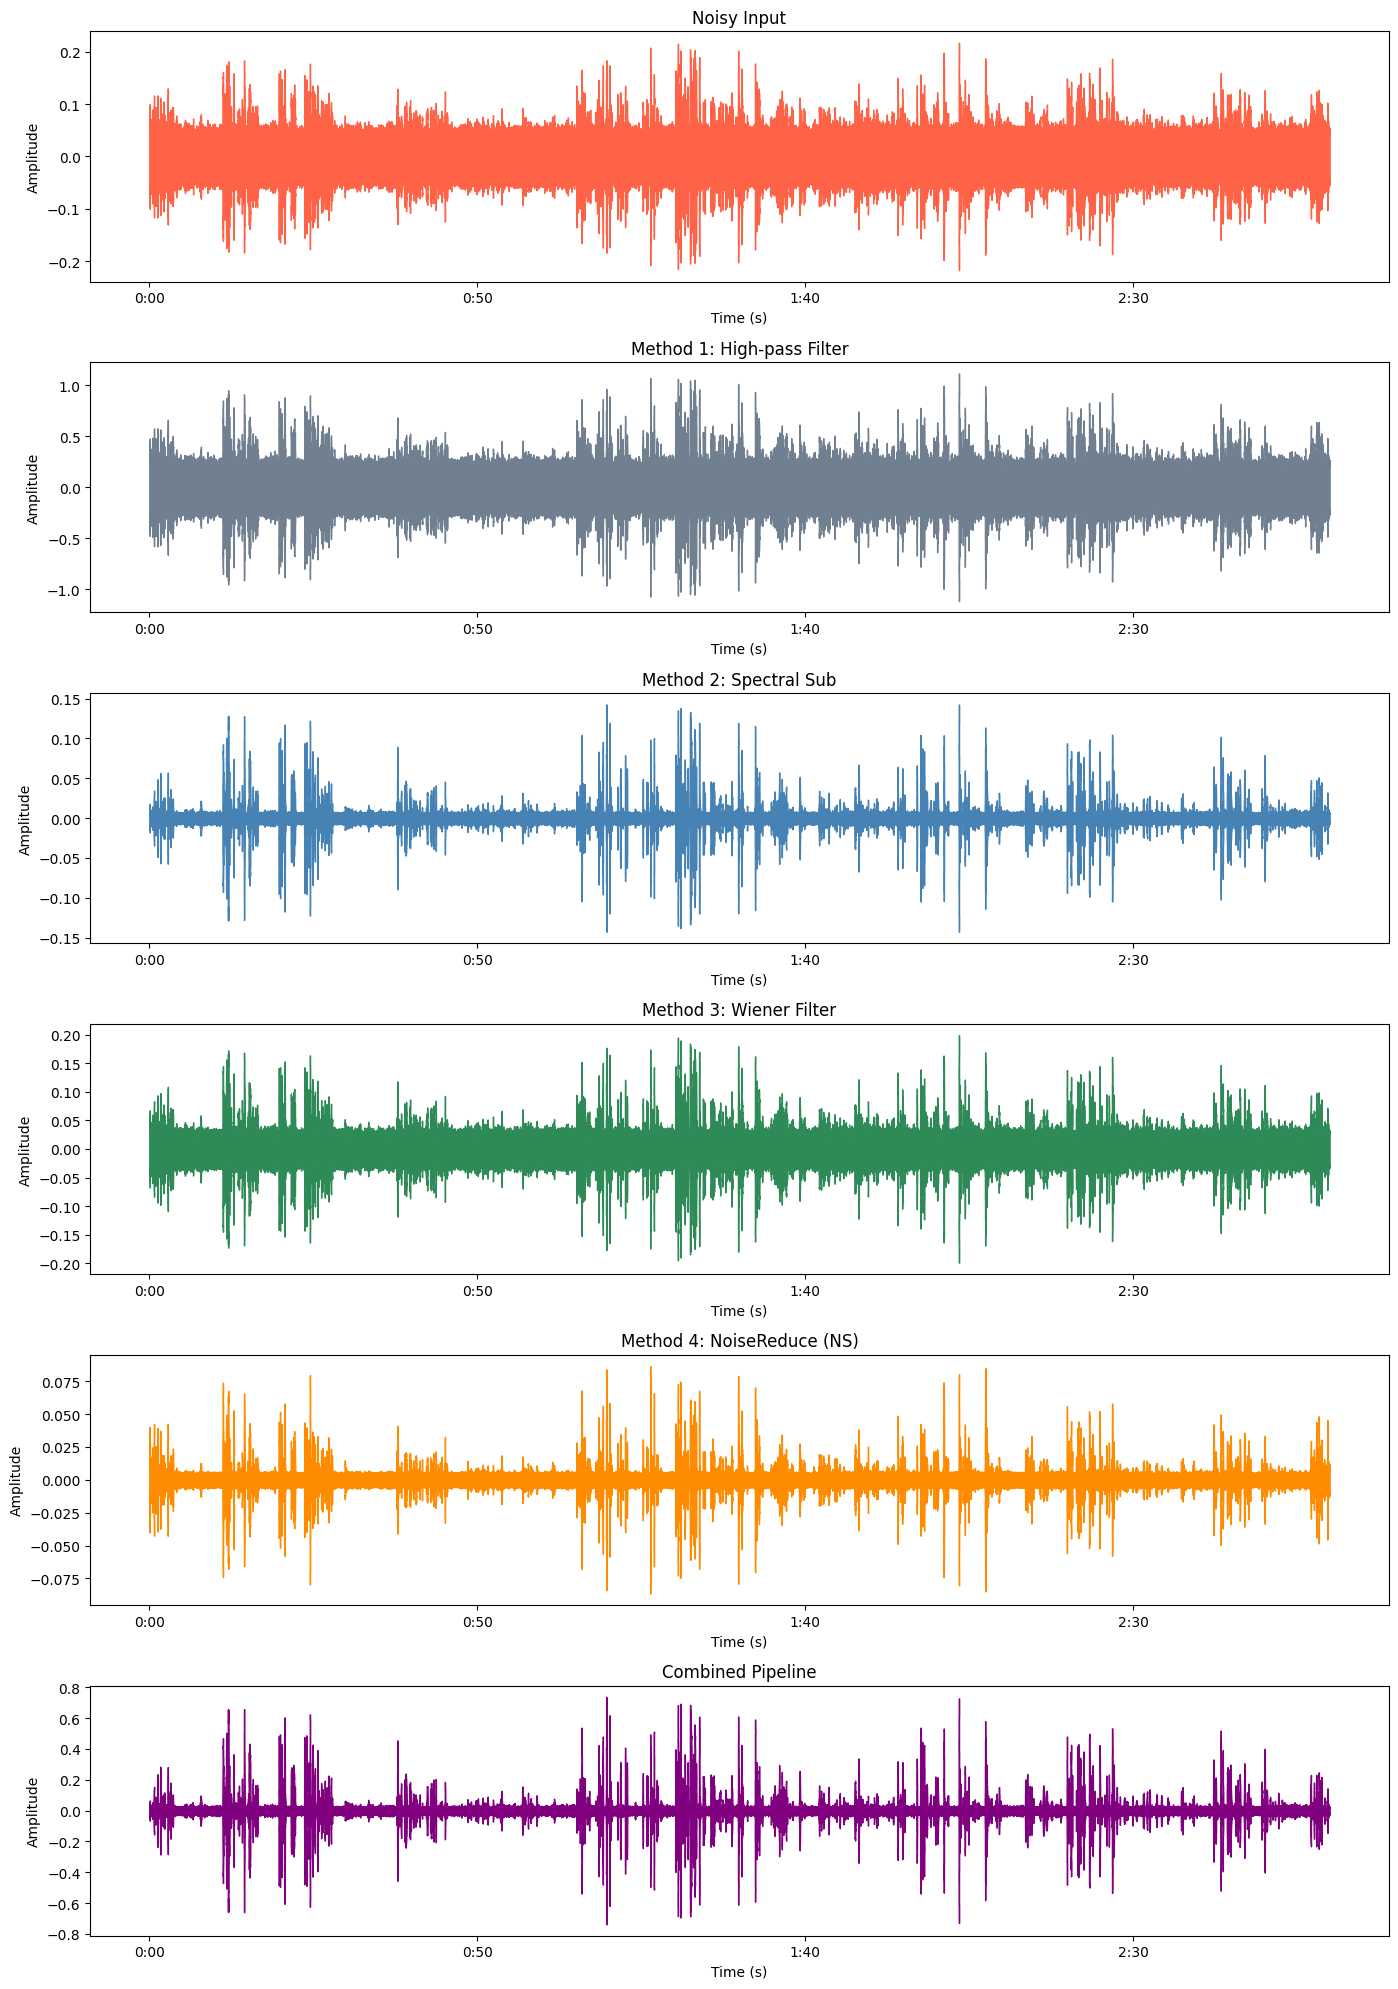

Waveform comparison saved → waveform_comparison.png


In [11]:
fig, axes = plt.subplots(6, 1, figsize=(14, 20))

signals_plot = [
    (y_noisy,   "Noisy Input",               "tomato"),
    (y_hp,      "Method 1: High-pass Filter", "slategray"),
    (y_ss,      "Method 2: Spectral Sub",     "steelblue"),
    (y_wiener,  "Method 3: Wiener Filter",    "seagreen"),
    (y_nr,      "Method 4: NoiseReduce (NS)", "darkorange"),
    (y_enhanced,"Combined Pipeline",          "purple"),
]

for ax, (sig, title, col) in zip(axes, signals_plot):
    librosa.display.waveshow(sig, sr=sr, ax=ax, color=col)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.savefig("waveform_comparison.png", dpi=150)
plt.show()
print("Waveform comparison saved → waveform_comparison.png")

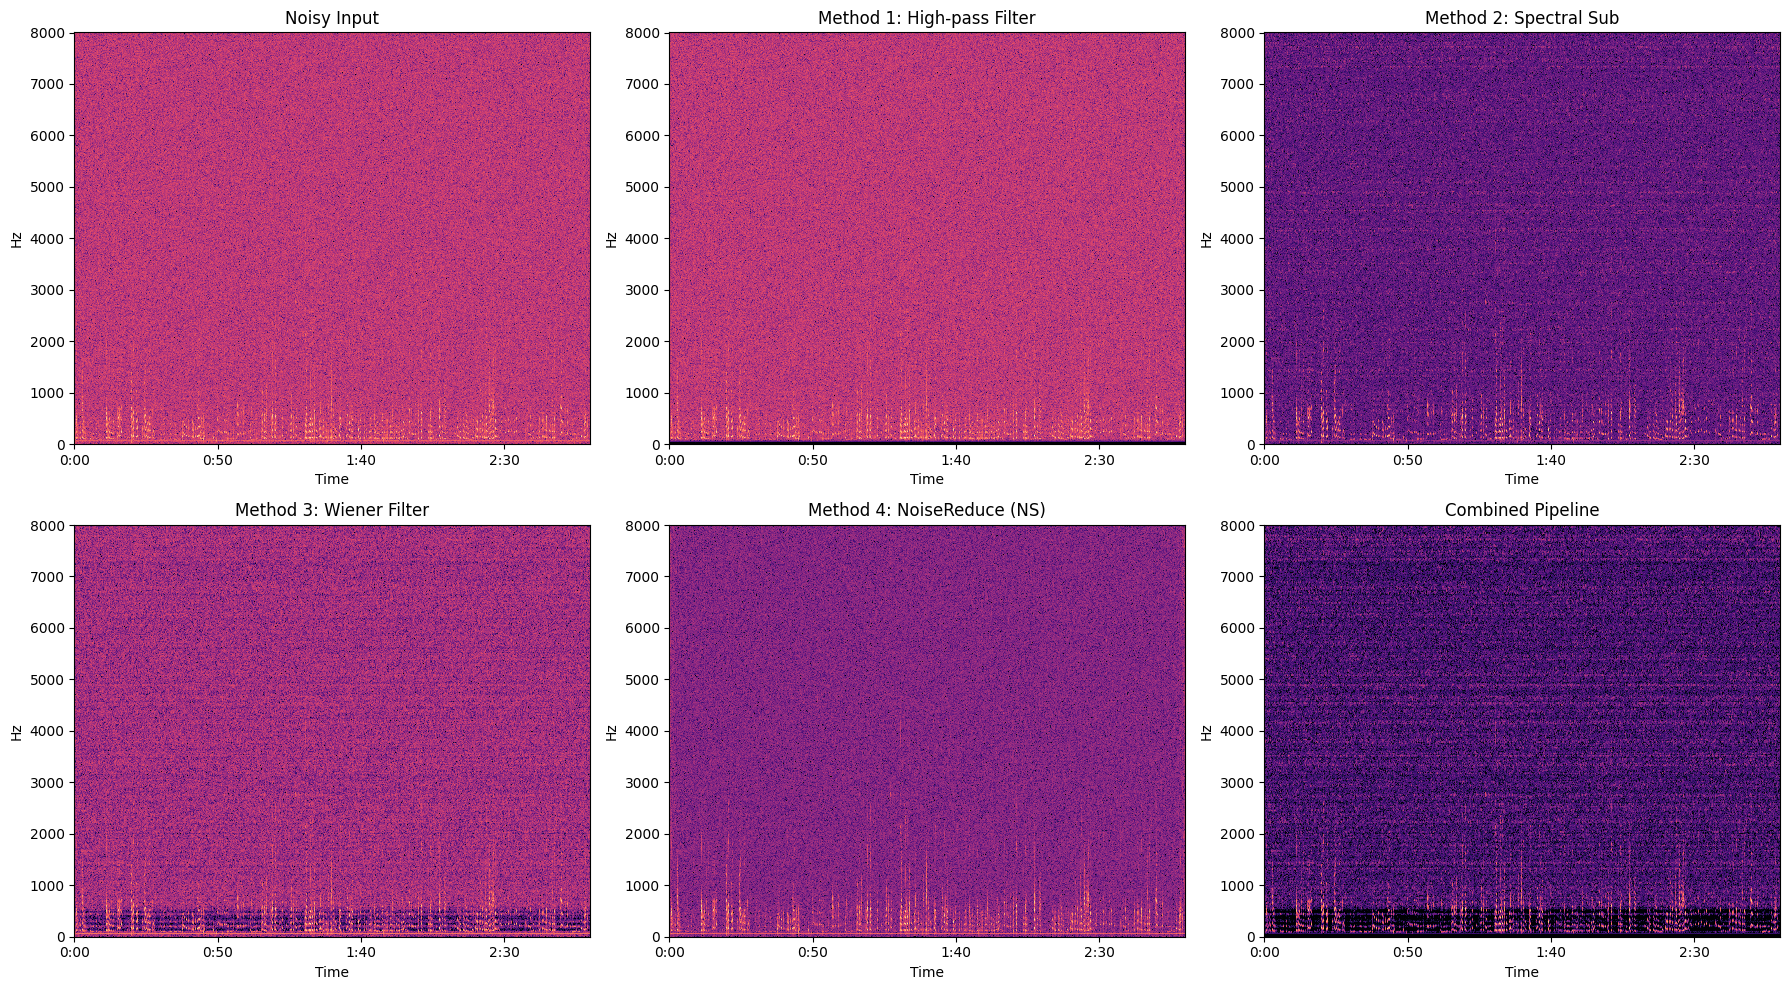

Spectrogram comparison saved → spectrogram_comparison.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

signals_spec = [
    (y_noisy,    "Noisy Input"),
    (y_hp,       "Method 1: High-pass Filter"),
    (y_ss,       "Method 2: Spectral Sub"),
    (y_wiener,   "Method 3: Wiener Filter"),
    (y_nr,       "Method 4: NoiseReduce (NS)"),
    (y_enhanced, "Combined Pipeline"),
]

for ax, (sig, title) in zip(axes.flatten(), signals_spec):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=ax, cmap="magma")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("spectrogram_comparison.png", dpi=150)
plt.show()
print("Spectrogram comparison saved → spectrogram_comparison.png")

In [18]:
from pystoi import stoi
import torch
from torchmetrics.functional.audio.dnsmos import deep_noise_suppression_mean_opinion_score

def calc_snr(clean, test):
    min_len = min(len(clean), len(test))
    noise = clean[:min_len] - test[:min_len]
    return 10 * np.log10(np.mean(clean[:min_len] ** 2) / (np.mean(noise ** 2) + 1e-10))

def calc_rms(x):
    return np.sqrt(np.mean(x ** 2))

def spec_flatness(x):
    S = np.abs(librosa.stft(x))
    g = np.exp(np.mean(np.log(S + 1e-10)))
    a = np.mean(S)
    return g / (a + 1e-10)

def calc_stoi(ref, deg, sr):
    min_len = min(len(ref), len(deg))
    try:
        return stoi(ref[:min_len], deg[:min_len], sr, extended=False)
    except Exception:
        return None

def calc_dnsmos(audio, sr):
    """
    Real DNSMOS P.835, Microsoft's non-intrusive perceptual quality metric.
    No clean reference signal needed. Returns OVRL MOS score (1–5 scale).
    Source: Reddy et al., ICASSP 2022: https://arxiv.org/abs/2110.01763
    """
    tensor = torch.tensor(audio, dtype=torch.float64)
    scores = deep_noise_suppression_mean_opinion_score(tensor, sr, personalized=False)
    return round(float(scores[-1]), 3)  # mos_ovr

ref = y[:min(len(y), len(y_noisy))]

signals_eval = {
    "Noisy":             y_noisy,
    "High-pass":         y_hp,
    "Spectral Sub":      y_ss,
    "Wiener":            y_wiener,
    "NoiseReduce (NS)":  y_nr,
    "Combined Pipeline": y_enhanced,
}

print("=" * 105)
print(f"{'Method':<22}  {'SNR (dB)':>9}       {'RMS':>8}                  {'Spec Flat':>10}       {'STOI':>7}       {'DNSMOS':>8}")
print("=" * 105)

for name, sig in signals_eval.items():
    snr_val    = round(calc_snr(ref, sig), 2)
    rms_val    = round(calc_rms(sig), 5)
    sf_val     = round(spec_flatness(sig), 5)
    stoi_val   = calc_stoi(ref, sig, sr)
    dnsmos_val = calc_dnsmos(sig, sr)
    stoi_str   = f"{stoi_val:.3f}" if stoi_val is not None else "N/A"
    print(f"{name:<22} {snr_val:>9}       {rms_val:>8}       {sf_val:>10}        {stoi_str:>7}        {dnsmos_val:>8}")

print("=" * 105)
print("SNR    : higher = less noise relative to signal")
print("STOI   : 0–1 | >0.85 = comfortably intelligible for transcription")
print("DNSMOS : 1–5 MOS scale | higher = better perceptual quality (no reference needed)")
print("         [SIG = speech quality, BAK = background, OVRL = overall]")

Method                   SNR (dB)            RMS                   Spec Flat          STOI         DNSMOS
Noisy                      -2.16       0.020339999347925186          0.80202          0.621           1.324
High-pass                 -17.38       0.10000000149011612          0.78772          0.621           1.428
Spectral Sub                4.75       0.00750999990850687           0.6371          0.610           1.421
Wiener                      1.74       0.014600000344216824          0.69159          0.638           1.288
NoiseReduce (NS)            2.55       0.004089999943971634          0.72156          0.633           1.725
Combined Pipeline          -6.87       0.037300001829862595          0.44799          0.582           1.275
SNR    : higher = less noise relative to signal
STOI   : 0–1 | >0.85 = comfortably intelligible for transcription
DNSMOS : 1–5 MOS scale | higher = better perceptual quality (no reference needed)
         [SIG = speech quality, BAK = background, OV

## Conclusion

In this notebook, I tested four audio enhancement methods on a noisy AMI IHM 
team communication sample and measured each one using five metrics.

| Method | SNR (dB) | RMS | Spec Flat | STOI | DNSMOS |
|---|---|---|---|---|---|
| Noisy (baseline) | -2.16 | 0.02034 | 0.802 | 0.621 | 1.324 |
| High-pass Filter | -17.38 | 0.10000 | 0.788 | 0.621 | 1.428 |
| Spectral Sub | 4.75 | 0.00751 | 0.637 | 0.610 | 1.421 |
| Wiener Filter | 1.74 | 0.01460 | 0.692 | 0.638 | 1.288 |
| NoiseReduce (NS) | 2.55 | 0.00409 | 0.722 | 0.633 | 1.725 |
| Combined Pipeline | -6.87 | 0.03730 | 0.448 | 0.582 | 1.275 |

### What the numbers show

**SNR** : Spectral subtraction got the highest SNR (4.75 dB), but SNR alone 
is not a reliable measure of speech quality. A method can boost SNR by 
suppressing parts of the signal along with the noise, which actually hurts 
intelligibility.

**STOI** : The Wiener filter scored highest here (0.638), meaning it preserved 
speech content the best. Spectral subtraction actually dropped below the noisy 
baseline (0.610 vs 0.621), which shows that aggressive noise removal can 
distort speech in the process. The combined pipeline scored lowest (0.582), 
meaning stacking all three methods together introduced too much over-processing.

**DNSMOS** : NoiseReduce came out on top (1.725), and this is the result I 
think matters most for this project. DNSMOS does not need a clean reference 
file to compute a score, which makes it the most realistic metric here. In 
TRIP Lab's actual studies, there will be no clean reference recording to 
compare against, so a metric that works without one is far more useful than 
SNR or STOI in practice.

### Which method works best

Looking at all five metrics together, NoiseReduce (NS) is the most balanced 
option. It gets positive SNR (2.55 dB), near-best STOI (0.633), and the 
highest DNSMOS (1.725) by a clear margin. It also handles non-stationary 
noise, meaning it adapts as background conditions change throughout a 
recording, which is important for real team communication sessions.

The Wiener filter is a solid classical fallback, especially if compute is 
limited, since it had the best STOI overall.

The combined pipeline performed worst on both STOI and DNSMOS despite being 
the most complex, which is a good reminder that adding more processing steps 
does not always help.

### Generated Files

| File | Description |
|---|---|
| `sample_input.wav` | Original clean AMI IHM audio |
| `sample_noisy.wav` | Noisy version with Gaussian noise and 60Hz hum |
| `enhanced_highpass.wav` | Method 1 output |
| `enhanced_spectral_subtraction.wav` | Method 2 output |
| `enhanced_wiener.wav` | Method 3 output |
| `enhanced_noisereduce.wav` | Method 4 output |
| `sample_output.wav` | Combined pipeline output |